# PROJET : Turnover & Prédiction de Départ RH

---

## Contexte métier

Le **turnover** (taux de rotation du personnel) est l'un des indicateurs RH les plus critiques pour une entreprise.  
Un turnover élevé génère des coûts importants :
- Coûts de recrutement (annonces, cabinet, temps RH)
- Coûts de formation des nouveaux entrants
- Perte de productivité pendant la période de montée en compétences
- Impact sur le moral des équipes restantes

Selon les études, **remplacer un employé coûte entre 50% et 200% de son salaire annuel** selon son niveau de séniorité.

## Objectifs du projet

1. **Auditer** la qualité des données RH sources (problèmes fréquents dans les SIRH)
2. **Analyser** les facteurs de départ : qui part, quand, et pourquoi ?
3. **Modéliser** la probabilité de départ avec une régression logistique
4. **Identifier** les profils à risque pour agir en amont
5. **Formuler** des recommandations RH actionnables

## Stack technique

Python · Pandas · NumPy · Matplotlib · Seaborn · Scikit-learn · SciPy

---

## Plan du notebook

| Section | Contenu |
|---------|----------|
| 1. Import & Génération | Données de 500 employés avec 8 types de défauts |
| 2. Audit Qualité | Complétude, doublons, cohérence, outliers |
| 3. Nettoyage | Correction traçable de chaque problème |
| 4. EDA | Distributions, corrélations, segmentations |
| 5. Analyse Turnover | Taux par département, ancienneté, poste |
| 6. Modèle Prédictif | Régression logistique + métriques |
| 7. Feature Importance | Quels facteurs expliquent le départ ? |
| 8. Insights & Recommandations | Plan d'action RH |

---
## 1. Import & Génération des données

### Pourquoi générer des données ?
Dans un contexte réel, on extrairait ces données du SIRH (SAP SuccessFactors, Workday, etc.).  
Les données RH contiennent souvent **de nombreuses erreurs** : saisies manuelles, exports mal configurés, migrations entre systèmes, etc.  
On simule ici ces problèmes pour s'entraîner à les détecter et les corriger.

### Variables simulées
| Variable | Description | Erreurs introduites |
|----------|-------------|---------------------|
| `employee_id` | Identifiant unique | Doublons |
| `nom` | Nom de l'employé | Noms manquants |
| `departement` | Service | Variantes orthographiques |
| `poste` | Intitulé de poste | OK |
| `salaire` | Salaire annuel brut (€) | Valeurs négatives, outliers |
| `age` | Âge | Valeurs impossibles (> 80, < 18) |
| `anciennete` | Années dans l'entreprise | Valeurs négatives |
| `satisfaction_score` | Score satisfaction (1-5) | Valeurs manquantes, hors bornes |
| `performance_score` | Score performance (1-5) | Hors bornes |
| `nb_projets` | Nombre de projets | OK |
| `heures_sup` | Heures sup par semaine | Outliers extrêmes |
| `distance_km` | Distance domicile-bureau | OK |
| `formation_annee` | Formations suivies l'année | OK |
| `dernier_promo` | Années depuis dernière promotion | OK |
| `genre` | Genre | Encodages incohérents |
| `contrat` | Type de contrat | OK |
| `date_embauche` | Date d'entrée | Incohérences chronologiques |
| `date_depart` | Date de sortie (si départ) | Antérieure à date d'embauche |
| `turnover` | 1 = a quitté, 0 = toujours là | Variable cible |

In [1]:
# ── IMPORTS ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (11, 5)

# Seed de reproductibilité : garantit les mêmes résultats à chaque exécution
np.random.seed(42)
N = 500  # taille de l'échantillon

In [2]:
# ── GÉNÉRATION DES DONNÉES PROPRES ────────────────────────────────────────────
# On construit d'abord un dataset sans erreurs, puis on introduit les défauts
# de façon contrôlée pour simuler une extraction SIRH réelle.

departements = ['Tech', 'Finance', 'Marketing', 'RH', 'Operations', 'Commercial']
postes = ['Analyste', 'Senior Analyste', 'Manager', 'Senior Manager', 'Directeur']
contrats = ['CDI', 'CDD', 'Stage', 'Alternance']

# Mapping poste -> niveau salarial de base
salaire_base = {
    'Analyste': 35000, 'Senior Analyste': 48000, 'Manager': 62000,
    'Senior Manager': 78000, 'Directeur': 95000
}

# Génération des postes avec pondération réaliste (pyramide des postes)
poste_col = np.random.choice(
    postes, size=N, p=[0.35, 0.30, 0.20, 0.10, 0.05]
)

# Salaire = base du poste + bruit gaussien ± 15%
salaire_col = np.array([
    int(salaire_base[p] * np.random.normal(1.0, 0.15))
    for p in poste_col
])

# Âge : corrélé au poste (les directeurs sont plus âgés)
age_base = {'Analyste': 26, 'Senior Analyste': 32, 'Manager': 38,
            'Senior Manager': 44, 'Directeur': 50}
age_col = np.array([
    int(np.random.normal(age_base[p], 4))
    for p in poste_col
])

# Ancienneté : corrélée à l'âge
anciennete_col = np.clip(
    (age_col - 22) * np.random.uniform(0.3, 0.7, N), 0, 30
).astype(int)

# Satisfaction : facteur clé du turnover (loi bêta => distribution réaliste)
# Les insatisfaits (< 2.5) ont plus de chances de partir
satisfaction_col = np.round(
    np.random.beta(2, 2, N) * 4 + 1, 1
)  # valeurs entre 1 et 5

# Performance : distribution normale centrée sur 3
performance_col = np.round(
    np.clip(np.random.normal(3.0, 0.8, N), 1, 5), 1
)

# Heures supplémentaires : exponentielle tronquée (la plupart font peu)
heures_sup_col = np.round(
    np.clip(np.random.exponential(5, N), 0, 25), 1
)

# Distance domicile-bureau (km)
distance_col = np.round(
    np.clip(np.random.lognormal(2.5, 0.8, N), 1, 100), 1
)

# Nombre de projets en cours
nb_projets_col = np.random.randint(1, 8, N)

# Formations suivies dans l'année
formation_col = np.random.randint(0, 5, N)

# Années depuis la dernière promotion
dernier_promo_col = np.random.randint(0, 8, N)

# Genre
genre_col = np.random.choice(['H', 'F'], size=N, p=[0.52, 0.48])

# Contrat
contrat_col = np.random.choice(contrats, N, p=[0.70, 0.15, 0.10, 0.05])

# Dates d'embauche (entre 2010 et 2023)
date_embauche_col = pd.to_datetime('2010-01-01') + pd.to_timedelta(
    np.random.randint(0, 13 * 365, N), unit='D'
)

# Turnover : probabilité de départ influencée par la satisfaction et les heures sup
# Formule logistique : P(départ) = sigmoid(-1.5 + 1.2*(5-satisfaction) + 0.08*heures_sup)
logit = -1.5 + 1.2 * (5 - satisfaction_col) + 0.08 * heures_sup_col
prob_depart = 1 / (1 + np.exp(-logit))
turnover_col = (np.random.uniform(size=N) < prob_depart).astype(int)

# Date de départ : uniquement pour les partants (entre date embauche et aujourd'hui)
date_depart_col = pd.Series([None] * N)
for i in range(N):
    if turnover_col[i] == 1:
        # Départ entre 6 mois et ancienneté + 1 an après embauche
        delta_max = max(180, int(anciennete_col[i] * 365))
        delta = np.random.randint(180, delta_max + 1)
        date_depart_col[i] = date_embauche_col[i] + pd.Timedelta(days=delta)

# Noms synthétiques
prenoms = ['Alice','Bob','Clara','David','Emma','François','Giulia','Hugo',
           'Inès','Jules','Karine','Luc','Marie','Nicolas','Olivia','Paul']
noms_famille = ['Martin','Bernard','Dubois','Thomas','Robert','Petit','Leroy',
               'Simon','Laurent','Michel','Garcia','David','Bertrand','Moreau']
noms_col = [
    f"{np.random.choice(prenoms)} {np.random.choice(noms_famille)}"
    for _ in range(N)
]

# Assemblage du DataFrame propre
df_raw = pd.DataFrame({
    'employee_id': range(1001, 1001 + N),
    'nom': noms_col,
    'departement': np.random.choice(departements, N),
    'poste': poste_col,
    'salaire': salaire_col,
    'age': age_col,
    'anciennete': anciennete_col,
    'satisfaction_score': satisfaction_col,
    'performance_score': performance_col,
    'nb_projets': nb_projets_col,
    'heures_sup': heures_sup_col,
    'distance_km': distance_col,
    'formation_annee': formation_col,
    'dernier_promo': dernier_promo_col,
    'genre': genre_col,
    'contrat': contrat_col,
    'date_embauche': date_embauche_col,
    'date_depart': date_depart_col,
    'turnover': turnover_col
})

print(f"Dataset propre généré : {df_raw.shape[0]} lignes × {df_raw.shape[1]} colonnes")
df_raw.head(3)

Dataset propre généré : 500 lignes × 19 colonnes


,employee_id,nom,departement,poste,salaire,age,anciennete,satisfaction_score,performance_score,nb_projets,heures_sup,distance_km,formation_annee,dernier_promo,genre,contrat,date_embauche,date_depart,turnover
0,1001,Luc Bertrand,Tech,Senior Analyste,50460,34,6,1.9,3.6,3,2.9,7.6,0,0,F,Stage,2017-05-20,2018-05-30 00:00:00,1
1,1002,Luc Michel,Marketing,Directeur,121735,48,14,4.3,3.6,7,6.8,5.8,4,7,F,CDI,2020-06-17,None,0
2,1003,Inès Robert,Commercial,Manager,70838,40,5,3.4,2.2,4,1.3,10.6,0,3,F,CDI,2020-03-07,None,0


In [3]:
# ── INJECTION DES DÉFAUTS QUALITÉ ─────────────────────────────────────────────
# On copie le dataset et on injecte des erreurs de façon aléatoire.
# Chaque erreur est documentée pour pouvoir la retrouver à l'audit.

df = df_raw.copy()

# DÉFAUT 1 : Doublons d'employee_id (5 lignes dupliquées)
# → Cause réelle : export SIRH avec jointure mal configurée
idx_dup = np.random.choice(df.index, size=5, replace=False)
df = pd.concat([df, df.loc[idx_dup]], ignore_index=True)
print(f"Défaut 1 – Doublons ajoutés : 5 lignes (total = {len(df)})")

# DÉFAUT 2 : Valeurs manquantes dans satisfaction_score (8% des lignes)
# → Cause réelle : champ facultatif dans l'enquête annuelle
idx_na_sat = np.random.choice(df.index, size=int(len(df)*0.08), replace=False)
df.loc[idx_na_sat, 'satisfaction_score'] = np.nan
print(f"Défaut 2 – Satisfaction manquante : {len(idx_na_sat)} lignes")

# DÉFAUT 3 : Valeurs manquantes dans nom (3% des lignes)
# → Cause réelle : employés intérimaires non saisis dans le SIRH
idx_na_nom = np.random.choice(df.index, size=int(len(df)*0.03), replace=False)
df.loc[idx_na_nom, 'nom'] = np.nan
print(f"Défaut 3 – Noms manquants : {len(idx_na_nom)} lignes")

# DÉFAUT 4 : Salaires négatifs (3 cas) et outliers extrêmes (3 cas)
# → Cause réelle : saisie manuelle inversée, copier-coller erroné
idx_sal_neg = np.random.choice(df.index, size=3, replace=False)
df.loc[idx_sal_neg, 'salaire'] = -df.loc[idx_sal_neg, 'salaire']
idx_sal_out = np.random.choice(df.index, size=3, replace=False)
df.loc[idx_sal_out, 'salaire'] = 999999  # valeur aberrante évidente
print(f"Défaut 4 – Salaires négatifs : 3, outliers : 3")

# DÉFAUT 5 : Âges impossibles (< 18 ou > 75)
# → Cause réelle : erreur de saisie (ex: 19 saisi 91)
idx_age = np.random.choice(df.index, size=4, replace=False)
df.loc[idx_age[:2], 'age'] = np.random.choice([12, 15], size=2)   # trop jeunes
df.loc[idx_age[2:], 'age'] = np.random.choice([82, 95], size=2)   # trop vieux
print(f"Défaut 5 – Âges impossibles : 4 lignes")

# DÉFAUT 6 : Ancienneté négative (2 cas)
# → Cause réelle : dates inversées lors d'une migration système
idx_anc = np.random.choice(df.index, size=2, replace=False)
df.loc[idx_anc, 'anciennete'] = [-2, -5]
print(f"Défaut 6 – Ancienneté négative : 2 lignes")

# DÉFAUT 7 : Genres incohérents (encodages multiples)
# → Cause réelle : champ libre dans ancien système, standardisation manquante
idx_genre = np.random.choice(df.index, size=20, replace=False)
mauvais_genres = ['Homme', 'homme', 'M', 'male', 'Femme', 'femme', 'F', 'female', '1', '2']
df.loc[idx_genre, 'genre'] = np.random.choice(mauvais_genres, size=20)
print(f"Défaut 7 – Genres mal encodés : 20 lignes")

# DÉFAUT 8 : Date de départ AVANT date d'embauche (3 cas)
# → Cause réelle : erreur de format JJ/MM vs MM/JJ lors de l'export
partants_idx = df[df['turnover'] == 1].index.tolist()
if len(partants_idx) >= 3:
    idx_date = np.random.choice(partants_idx, size=3, replace=False)
    for i in idx_date:
        df.loc[i, 'date_depart'] = df.loc[i, 'date_embauche'] - pd.Timedelta(days=180)
print(f"Défaut 8 – Date départ antérieure à embauche : 3 lignes")

# DÉFAUT 9 : Performance hors bornes [1-5]
idx_perf = np.random.choice(df.index, size=5, replace=False)
df.loc[idx_perf[:3], 'performance_score'] = 7.5  # hors borne max
df.loc[idx_perf[3:], 'performance_score'] = -1   # valeur négative impossible
print(f"Défaut 9 – Performance hors bornes : 5 lignes")

# DÉFAUT 10 : Variantes orthographiques dans les départements
idx_dept = np.random.choice(df.index, size=15, replace=False)
variantes = ['tech', 'TECH', 'Finances', 'finance', 'R.H.', 'RH ', ' Marketing']
df.loc[idx_dept, 'departement'] = np.random.choice(variantes, size=15)
print(f"Défaut 10 – Départements mal orthographiés : 15 lignes")

# DÉFAUT 11 : Heures supplémentaires extrêmes (dépassant le légal)
# En France, le max légal est 220h/an soit ~4.2h/semaine de moyenne,
# mais certains enregistrements montrent 60h/semaine (probablement des cumulés annuels saisis en hebdo)
idx_hs = np.random.choice(df.index, size=4, replace=False)
df.loc[idx_hs, 'heures_sup'] = [60, 72, 55, 80]
print(f"Défaut 11 – Heures sup impossibles : 4 lignes")

print(f"\n✅ Dataset avec défauts : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"   Taux de turnover brut : {df['turnover'].mean():.1%}")

Défaut 1 – Doublons ajoutés : 5 lignes (total = 505)
Défaut 2 – Satisfaction manquante : 40 lignes
Défaut 3 – Noms manquants : 15 lignes
Défaut 4 – Salaires négatifs : 3, outliers : 3
Défaut 5 – Âges impossibles : 4 lignes
Défaut 6 – Ancienneté négative : 2 lignes
Défaut 7 – Genres mal encodés : 20 lignes
Défaut 8 – Date départ antérieure à embauche : 3 lignes
Défaut 9 – Performance hors bornes : 5 lignes
Défaut 10 – Départements mal orthographiés : 15 lignes
Défaut 11 – Heures sup impossibles : 4 lignes

✅ Dataset avec défauts : 505 lignes × 19 colonnes
   Taux de turnover brut : 73.3%


---
## 2. Audit de Qualité des Données

L'audit qualité est la **première étape indispensable** avant toute analyse.  
Il répond à 5 questions fondamentales :
1. **Complétude** : Mes données sont-elles bien renseignées ?
2. **Unicité** : Y a-t-il des doublons ?
3. **Validité** : Les valeurs sont-elles dans les plages attendues ?
4. **Cohérence** : Les données sont-elles cohérentes entre elles ?
5. **Exactitude** : Les catégories sont-elles standardisées ?

In [4]:
# ── 2.1 VUE D'ENSEMBLE ────────────────────────────────────────────────────────
print("=" * 60)
print("AUDIT QUALITÉ – Vue d'ensemble")
print("=" * 60)
print(f"Lignes      : {df.shape[0]}")
print(f"Colonnes    : {df.shape[1]}")
print()
print(df.dtypes)
print()
df.describe(include='all').round(2)

AUDIT QUALITÉ – Vue d'ensemble
Lignes      : 505
Colonnes    : 19

employee_id                    int64
nom                              str
departement                      str
poste                            str
salaire                        int64
age                            int64
anciennete                     int64
satisfaction_score           float64
performance_score            float64
nb_projets                     int64
heures_sup                   float64
distance_km                  float64
formation_annee                int64
dernier_promo                  int64
genre                            str
contrat                          str
date_embauche         datetime64[us]
date_depart                   object
turnover                       int64
dtype: object



,employee_id,nom,departement,poste,salaire,age,anciennete,satisfaction_score,performance_score,nb_projets,heures_sup,distance_km,formation_annee,dernier_promo,genre,contrat,date_embauche,date_depart,turnover
count,505.00,490,505,505,505.00,505.00,505.00,465.00,505.00,505.00,505.00,505.00,505.00,505.00,505,505,505,370,505.00
unique,NaN,200,12,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9,4,NaN,357,NaN
top,NaN,Luc Martin,Tech,Analyste,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,H,CDI,NaN,2018-04-04 00:00:00,NaN
freq,NaN,7,87,183,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,264,371,NaN,2,NaN
mean,1250.50,NaN,NaN,NaN,56897.98,33.09,5.09,2.98,2.96,4.04,5.44,16.39,1.90,3.46,NaN,NaN,2016-05-08 09:38:51.089109,NaN,0.73
min,1001.00,NaN,NaN,NaN,-66528.00,12.00,-5.00,1.00,-1.00,1.00,0.00,1.00,0.00,0.00,NaN,NaN,2010-01-12 00:00:00,NaN,0.00
25%,1127.00,NaN,NaN,NaN,36518.00,26.00,2.00,2.30,2.40,2.00,1.50,7.20,1.00,1.00,NaN,NaN,2012-12-15 00:00:00,NaN,0.00
50%,1250.00,NaN,NaN,NaN,47638.00,32.00,4.00,3.00,3.00,4.00,3.40,12.10,2.00,3.00,NaN,NaN,2016-06-30 00:00:00,NaN,1.00
75%,1374.00,NaN,NaN,NaN,62226.00,39.00,8.00,3.60,3.50,6.00,6.70,21.10,3.00,6.00,NaN,NaN,2019-07-28 00:00:00,NaN,1.00
max,1500.00,NaN,NaN,NaN,999999.00,82.00,22.00,4.90,7.50,7.00,80.00,100.00,4.00,7.00,NaN,NaN,2022-12-26 00:00:00,NaN,1.00



📊 COMPLÉTUDE – Valeurs manquantes :
                    nb_manquants  pct_manquants
date_depart                  135          26.73
satisfaction_score            40           7.92
nom                           15           2.97


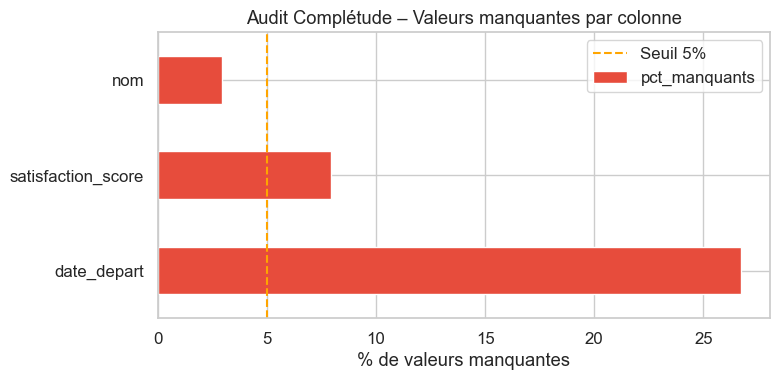

In [5]:
# ── 2.2 COMPLÉTUDE – Valeurs manquantes ───────────────────────────────────────
# On calcule le nombre et le % de NaN par colonne.
# Règle métier : toute colonne > 5% de NaN nécessite un plan de traitement.

missing = pd.DataFrame({
    'nb_manquants': df.isnull().sum(),
    'pct_manquants': (df.isnull().sum() / len(df) * 100).round(2)
}).query('nb_manquants > 0').sort_values('pct_manquants', ascending=False)

print("\n📊 COMPLÉTUDE – Valeurs manquantes :")
print(missing.to_string())

# Visualisation
fig, ax = plt.subplots(figsize=(8, 4))
missing['pct_manquants'].plot(kind='barh', ax=ax, color='#E74C3C')
ax.axvline(5, color='orange', linestyle='--', label='Seuil 5%')
ax.set_xlabel('% de valeurs manquantes')
ax.set_title('Audit Complétude – Valeurs manquantes par colonne')
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# ── 2.3 UNICITÉ – Doublons ────────────────────────────────────────────────────
# Un doublon sur employee_id est CRITIQUE : il fausse tous les KPIs agrégés.

nb_doublons_total = df.duplicated().sum()
nb_doublons_id = df.duplicated(subset='employee_id').sum()

print(f"\n🔁 UNICITÉ :")
print(f"   Lignes entièrement dupliquées   : {nb_doublons_total}")
print(f"   IDs dupliqués (employee_id)     : {nb_doublons_id}")

# Afficher les IDs concernés
ids_dup = df[df.duplicated(subset='employee_id', keep=False)]['employee_id'].unique()
print(f"   IDs concernés : {ids_dup[:10]}")


🔁 UNICITÉ :
   Lignes entièrement dupliquées   : 2
   IDs dupliqués (employee_id)     : 5
   IDs concernés : [1176 1181 1239 1319 1336]


In [7]:
# ── 2.4 VALIDITÉ – Plages et contraintes métier ───────────────────────────────
# On définit les règles métier et on compte les violations.

print("\n✅ VALIDITÉ – Violations des règles métier :")
print("-" * 50)

checks = {
    'Salaire ≤ 0'            : (df['salaire'] <= 0).sum(),
    'Salaire > 500 000 €'    : (df['salaire'] > 500_000).sum(),
    'Âge < 18 ans'           : (df['age'] < 18).sum(),
    'Âge > 75 ans'           : (df['age'] > 75).sum(),
    'Ancienneté < 0'         : (df['anciennete'] < 0).sum(),
    'Satisfaction hors [1,5]': ((df['satisfaction_score'] < 1) | (df['satisfaction_score'] > 5)).sum(),
    'Performance hors [1,5]' : ((df['performance_score'] < 1) | (df['performance_score'] > 5)).sum(),
    'Heures sup > 40/sem'    : (df['heures_sup'] > 40).sum(),
}

for regle, nb in checks.items():
    statut = '🔴' if nb > 0 else '🟢'
    print(f"   {statut} {regle:<30} : {nb} cas")

# Incohérence temporelle : date_depart < date_embauche
partants = df[df['turnover'] == 1].copy()
partants['date_embauche'] = pd.to_datetime(partants['date_embauche'])
partants['date_depart'] = pd.to_datetime(partants['date_depart'])
incoherence_dates = (partants['date_depart'] < partants['date_embauche']).sum()
print(f"   🔴 {'Date départ < Date embauche':<30} : {incoherence_dates} cas")


✅ VALIDITÉ – Violations des règles métier :
--------------------------------------------------
   🔴 Salaire ≤ 0                    : 3 cas
   🔴 Salaire > 500 000 €            : 3 cas
   🔴 Âge < 18 ans                   : 7 cas
   🔴 Âge > 75 ans                   : 2 cas
   🔴 Ancienneté < 0                 : 2 cas
   🟢 Satisfaction hors [1,5]        : 0 cas
   🔴 Performance hors [1,5]         : 5 cas
   🔴 Heures sup > 40/sem            : 4 cas
   🔴 Date départ < Date embauche    : 3 cas


In [8]:
# ── 2.5 EXACTITUDE – Catégories non standardisées ────────────────────────────

print("\n📝 EXACTITUDE – Valeurs uniques des catégories :")
for col in ['genre', 'departement', 'contrat', 'poste']:
    vals = df[col].value_counts()
    print(f"\n  {col.upper()} ({df[col].nunique()} valeurs uniques) :")
    print(vals.to_string())


📝 EXACTITUDE – Valeurs uniques des catégories :

  GENRE (9 valeurs uniques) :
genre
H         264
F         223
2           4
M           4
Homme       4
male        2
female      2
1           1
femme       1

  DEPARTEMENT (12 valeurs uniques) :
departement
Tech          87
RH            87
Operations    82
Marketing     80
Commercial    80
Finance       74
finance        4
tech           3
Finances       3
 Marketing     2
TECH           2
RH             1

  CONTRAT (4 valeurs uniques) :
contrat
CDI           371
CDD            66
Stage          48
Alternance     20

  POSTE (5 valeurs uniques) :
poste
Analyste           183
Senior Analyste    149
Manager             90
Senior Manager      53
Directeur           30


In [9]:
# ── 2.6 RAPPORT QUALITÉ GLOBAL ────────────────────────────────────────────────
# On calcule un score global de qualité sur 5 dimensions.

total_cellules = df.shape[0] * df.shape[1]

score_completude = 1 - df.isnull().sum().sum() / total_cellules
score_unicite = 1 - nb_doublons_total / len(df)
score_validite = 1 - sum(checks.values()) / len(df)
score_coherence = 1 - incoherence_dates / max(len(partants), 1)
# Exactitude : % de lignes avec genre et departement bien encodés
genres_valides = df['genre'].isin(['H', 'F']).sum()
score_exactitude = genres_valides / len(df)

score_global = np.mean([score_completude, score_unicite, score_validite,
                        score_coherence, score_exactitude]) * 100

print("\n" + "=" * 55)
print("RAPPORT QUALITÉ GLOBAL")
print("=" * 55)
print(f"  Complétude   : {score_completude:.1%}")
print(f"  Unicité      : {score_unicite:.1%}")
print(f"  Validité     : {score_validite:.1%}")
print(f"  Cohérence    : {score_coherence:.1%}")
print(f"  Exactitude   : {score_exactitude:.1%}")
print(f"\n  ⭐ SCORE GLOBAL : {score_global:.1f} / 100")
print("=" * 55)


RAPPORT QUALITÉ GLOBAL
  Complétude   : 98.0%
  Unicité      : 99.6%
  Validité     : 94.9%
  Cohérence    : 99.2%
  Exactitude   : 96.4%

  ⭐ SCORE GLOBAL : 97.6 / 100


---
## 3. Nettoyage des Données

Chaque opération de nettoyage doit être :
- **Traçable** : on documente ce qu'on fait et pourquoi
- **Conservative** : on ne supprime que ce qu'on ne peut pas récupérer
- **Auditable** : on compare les stats avant/après

**Ordre recommandé :**
1. Supprimer les doublons (évite de biaiser les imputations)
2. Standardiser les catégories (permet les regroupements)
3. Corriger les valeurs invalides
4. Imputer les valeurs manquantes
5. Supprimer les lignes irrécupérables

In [10]:
df_clean = df.copy()
n_initial = len(df_clean)

# ── ÉTAPE 1 : Supprimer les doublons ─────────────────────────────────────────
# On garde la première occurrence de chaque employee_id.
# En production on vérifierait quelle occurrence est la plus récente/complète.
df_clean = df_clean.drop_duplicates(subset='employee_id', keep='first')
print(f"[1] Doublons supprimés : {n_initial - len(df_clean)} lignes")

# ── ÉTAPE 2 : Standardiser les genres ────────────────────────────────────────
# Mapping exhaustif de toutes les variantes trouvées vers H/F
mapping_genre = {
    'H': 'H', 'F': 'F',
    'Homme': 'H', 'homme': 'H', 'M': 'H', 'male': 'H', '1': 'H',
    'Femme': 'F', 'femme': 'F', 'female': 'F', '2': 'F'
}
df_clean['genre'] = df_clean['genre'].map(mapping_genre)
# Les valeurs non mappées deviennent NaN (on les traitera ensuite)
genres_invalides = df_clean['genre'].isnull().sum()
print(f"[2] Genres standardisés. Encore non mappés : {genres_invalides}")

# ── ÉTAPE 3 : Standardiser les départements ───────────────────────────────────
mapping_dept = {
    'Tech': 'Tech', 'tech': 'Tech', 'TECH': 'Tech',
    'Finance': 'Finance', 'Finances': 'Finance', 'finance': 'Finance',
    'RH': 'RH', 'R.H.': 'RH', 'RH ': 'RH',
    'Marketing': 'Marketing', ' Marketing': 'Marketing',
    'Operations': 'Operations', 'Commercial': 'Commercial'
}
df_clean['departement'] = df_clean['departement'].str.strip().map(mapping_dept)
print(f"[3] Départements standardisés. Non mappés : {df_clean['departement'].isnull().sum()}")

# ── ÉTAPE 4 : Corriger les salaires ──────────────────────────────────────────
# Salaires négatifs → valeur absolue (probablement signe inversé par erreur)
mask_neg = df_clean['salaire'] < 0
df_clean.loc[mask_neg, 'salaire'] = df_clean.loc[mask_neg, 'salaire'].abs()
# Salaires > 300 000 → outlier extrême, on remplace par la médiane du poste
for poste in df_clean['poste'].unique():
    mask_out = (df_clean['poste'] == poste) & (df_clean['salaire'] > 300_000)
    median_sal = int(df_clean.loc[df_clean['poste'] == poste, 'salaire'].median())
    df_clean.loc[mask_out, 'salaire'] = median_sal
print(f"[4] Salaires corrigés (négatifs + outliers)")

# ── ÉTAPE 5 : Supprimer les âges impossibles ──────────────────────────────────
mask_age_inv = (df_clean['age'] < 18) | (df_clean['age'] > 75)
df_clean = df_clean[~mask_age_inv]
print(f"[5] Lignes supprimées (âge impossible) : {mask_age_inv.sum()}")

# ── ÉTAPE 6 : Ancienneté négative → valeur absolue ───────────────────────────
df_clean['anciennete'] = df_clean['anciennete'].abs()
print(f"[6] Ancienneté négative corrigée")

# ── ÉTAPE 7 : Performance hors bornes → borne à [1, 5] ───────────────────────
df_clean['performance_score'] = df_clean['performance_score'].clip(1, 5)
print(f"[7] Performance clippée à [1, 5]")

# ── ÉTAPE 8 : Heures sup extrêmes → médiane du département ───────────────────
mask_hs = df_clean['heures_sup'] > 40
for dept in df_clean['departement'].dropna().unique():
    mask = mask_hs & (df_clean['departement'] == dept)
    med = df_clean.loc[df_clean['departement'] == dept, 'heures_sup'].median()
    df_clean.loc[mask, 'heures_sup'] = med
print(f"[8] Heures sup extrêmes corrigées : {mask_hs.sum()} lignes")

# ── ÉTAPE 9 : Incohérences de dates ──────────────────────────────────────────
df_clean['date_embauche'] = pd.to_datetime(df_clean['date_embauche'])
df_clean['date_depart'] = pd.to_datetime(df_clean['date_depart'])
mask_date_inv = (
    df_clean['turnover'] == 1
) & (
    df_clean['date_depart'] < df_clean['date_embauche']
)
# On met la date de départ à NaN et on conserve le flag turnover=1
df_clean.loc[mask_date_inv, 'date_depart'] = pd.NaT
print(f"[9] Dates incohérentes corrigées (date_depart → NaT) : {mask_date_inv.sum()}")

# ── ÉTAPE 10 : Imputation des valeurs manquantes ──────────────────────────────
# Satisfaction manquante → médiane par département (plus pertinent que la médiane globale)
# Pourquoi la médiane ? La moyenne est sensible aux outliers ; sur une échelle 1-5, la médiane est plus stable.
df_clean['satisfaction_score'] = df_clean.groupby('departement')['satisfaction_score'].transform(
    lambda x: x.fillna(x.median())
)
# Noms manquants → 'Anonyme'
df_clean['nom'] = df_clean['nom'].fillna('Anonyme')
# Genre manquant → 'Inconnu'
df_clean['genre'] = df_clean['genre'].fillna('Inconnu')
# Département manquant → 'Non assigné'
df_clean['departement'] = df_clean['departement'].fillna('Non assigné')
print(f"[10] Valeurs manquantes imputées")

n_final = len(df_clean)
print(f"\n✅ Nettoyage terminé : {n_initial} → {n_final} lignes ({n_initial - n_final} supprimées)")
print(f"   Valeurs manquantes restantes : {df_clean.isnull().sum().sum()}")

[1] Doublons supprimés : 5 lignes
[2] Genres standardisés. Encore non mappés : 0
[3] Départements standardisés. Non mappés : 0
[4] Salaires corrigés (négatifs + outliers)
[5] Lignes supprimées (âge impossible) : 8
[6] Ancienneté négative corrigée
[7] Performance clippée à [1, 5]
[8] Heures sup extrêmes corrigées : 3 lignes
[9] Dates incohérentes corrigées (date_depart → NaT) : 3
[10] Valeurs manquantes imputées

✅ Nettoyage terminé : 505 → 492 lignes (13 supprimées)
   Valeurs manquantes restantes : 135


---
## 4. Analyse Exploratoire (EDA)

L'EDA nous permet de **comprendre la structure des données** avant de modéliser.  
On cherche à répondre à : *À quoi ressemble ma population ? Comment les variables se distribuent-elles ? Quelles corrélations existent ?*

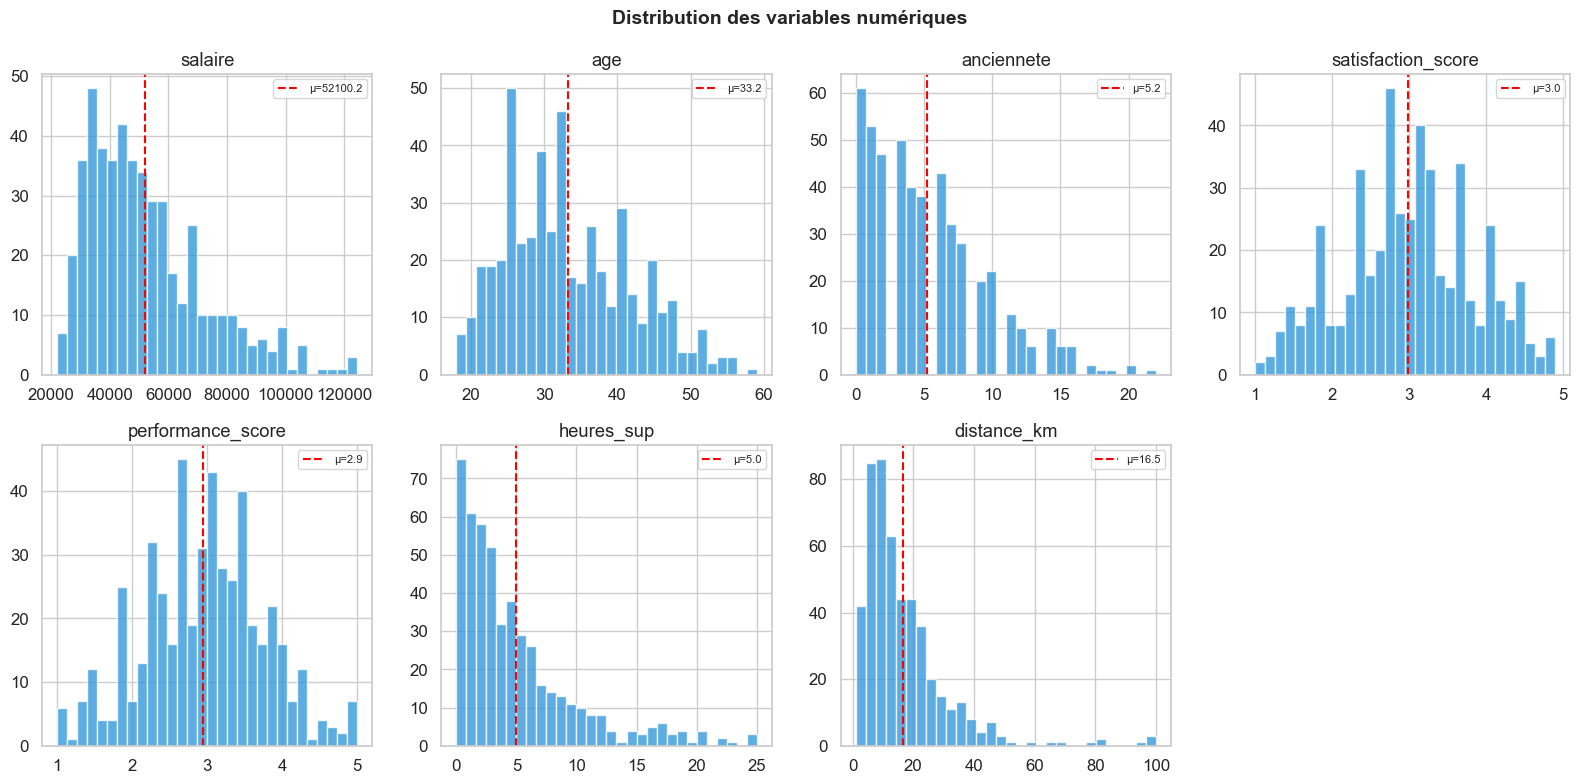

In [11]:
# ── 4.1 DISTRIBUTION DES VARIABLES NUMÉRIQUES ─────────────────────────────────
num_cols = ['salaire', 'age', 'anciennete', 'satisfaction_score',
            'performance_score', 'heures_sup', 'distance_km']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df_clean[col].dropna(), bins=30, color='#3498DB', edgecolor='white', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    mu = df_clean[col].mean()
    axes[i].axvline(mu, color='red', linestyle='--', label=f'μ={mu:.1f}')
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)  # masquer le dernier subplot vide
fig.suptitle('Distribution des variables numériques', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

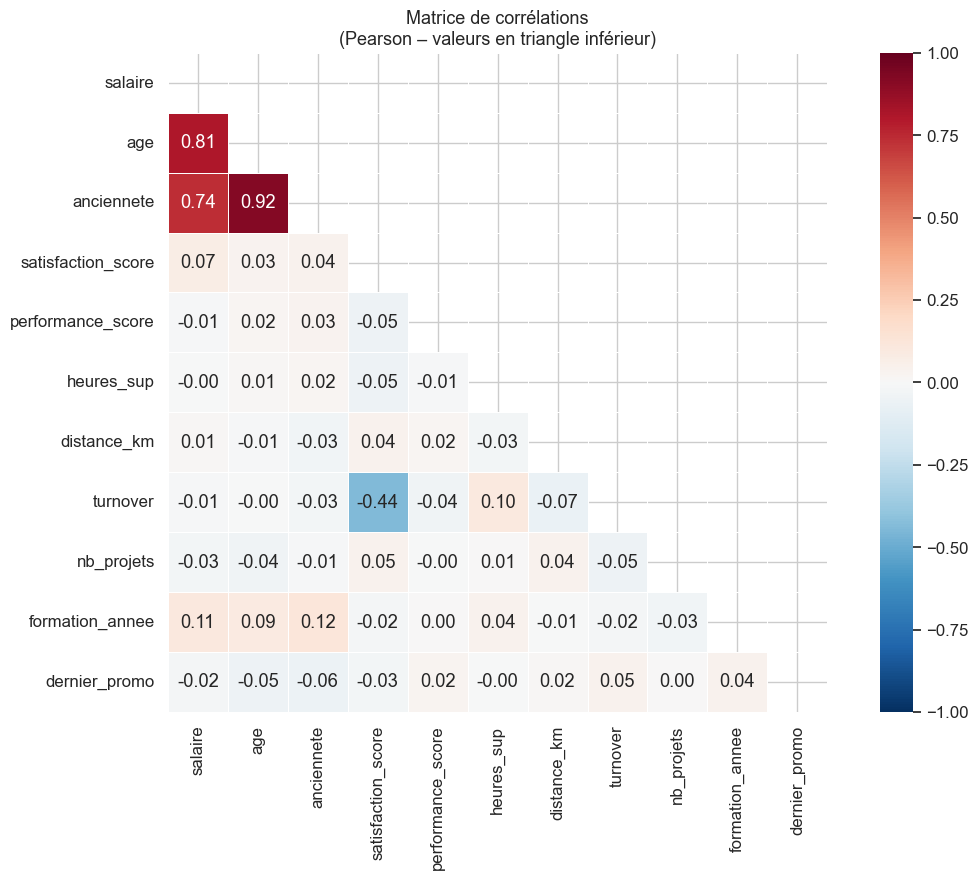


Corrélations avec le turnover (variable cible) :
satisfaction_score   -0.439
heures_sup            0.096
distance_km          -0.068
nb_projets           -0.050
dernier_promo         0.046
performance_score    -0.044
anciennete           -0.027
formation_annee      -0.023
salaire              -0.014
age                  -0.002


In [12]:
# ── 4.2 MATRICE DE CORRÉLATIONS ───────────────────────────────────────────────
# La corrélation de Pearson mesure la force de la relation linéaire entre deux variables.
# Valeurs entre -1 (inverse) et +1 (directe). 0 = pas de relation linéaire.

corr_cols = num_cols + ['turnover', 'nb_projets', 'formation_annee', 'dernier_promo']
corr_matrix = df_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # masque la moitié sup (redondante)
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5, square=True
)
ax.set_title('Matrice de corrélations\n(Pearson – valeurs en triangle inférieur)', fontsize=13)
plt.tight_layout()
plt.show()

# Corrélations avec le turnover (tri décroissant par valeur absolue)
print("\nCorrélations avec le turnover (variable cible) :")
corr_turnover = corr_matrix['turnover'].drop('turnover').sort_values(key=abs, ascending=False)
print(corr_turnover.round(3).to_string())

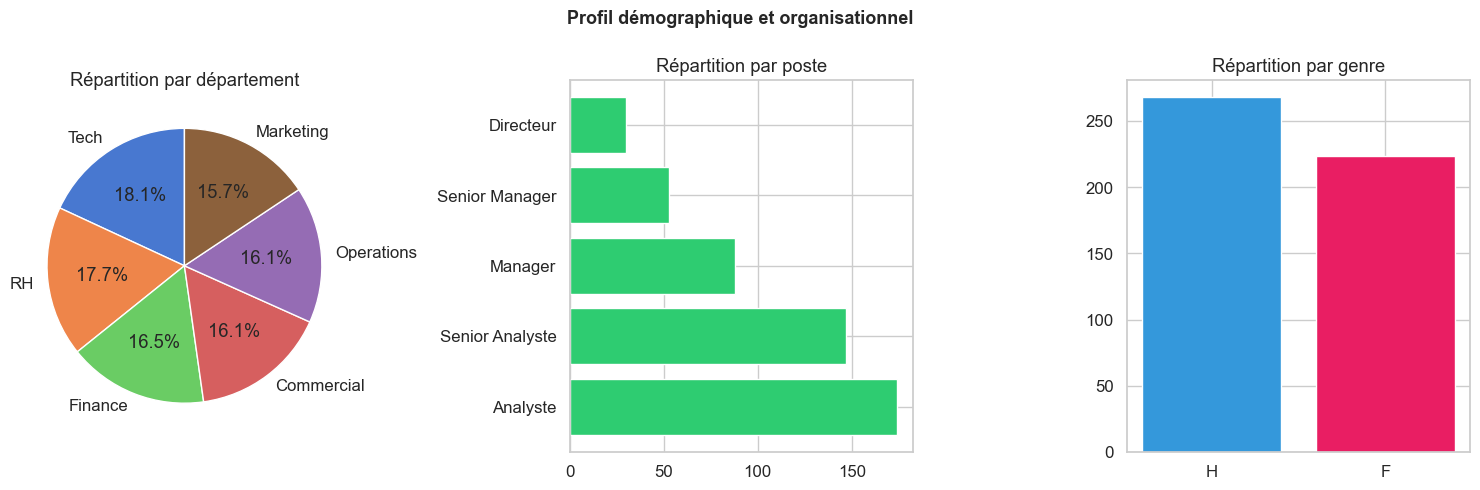

In [13]:
# ── 4.3 RÉPARTITION PAR CATÉGORIES ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Répartition par département
dept_counts = df_clean['departement'].value_counts()
axes[0].pie(dept_counts, labels=dept_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Répartition par département')

# Répartition par poste
poste_counts = df_clean['poste'].value_counts()
axes[1].barh(poste_counts.index, poste_counts.values, color='#2ECC71')
axes[1].set_title('Répartition par poste')

# Répartition par genre
genre_counts = df_clean['genre'].value_counts()
axes[2].bar(genre_counts.index, genre_counts.values,
            color=['#3498DB', '#E91E63', '#95A5A6'])
axes[2].set_title('Répartition par genre')

plt.suptitle('Profil démographique et organisationnel', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Analyse du Turnover

On analyse le turnover selon plusieurs **dimensions RH** pour identifier les segments à risque.

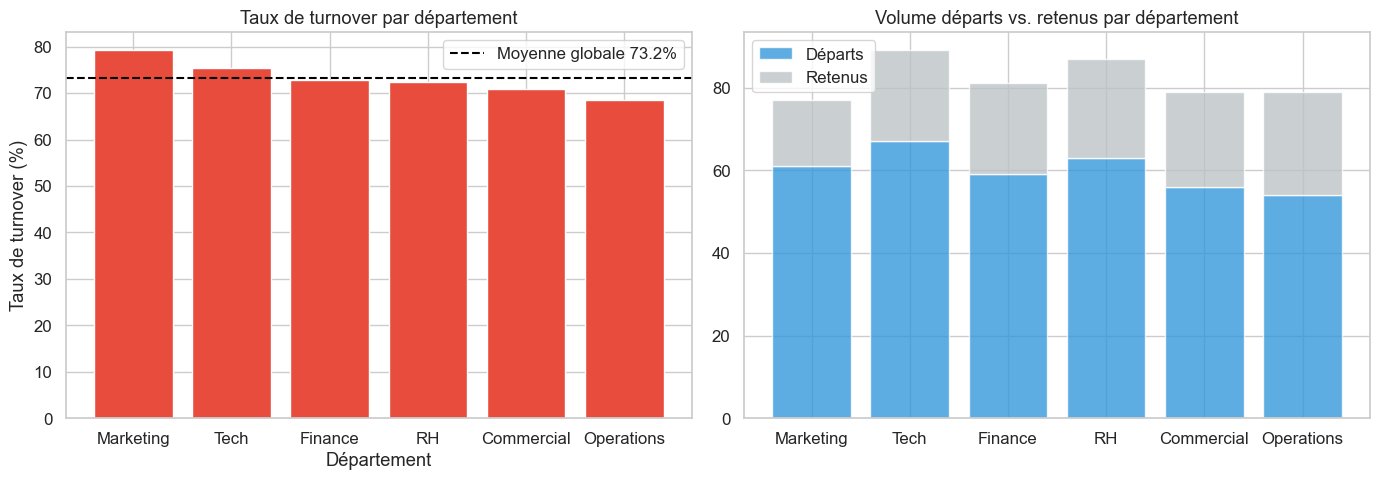

             effectif  departs  taux_pct
departement                             
Marketing          77       61      79.2
Tech               89       67      75.3
Finance            81       59      72.8
RH                 87       63      72.4
Commercial         79       56      70.9
Operations         79       54      68.4


In [14]:
# ── 5.1 TAUX DE TURNOVER PAR DÉPARTEMENT ─────────────────────────────────────
# Taux de turnover = nb départs / effectif total du département

turnover_dept = df_clean.groupby('departement').agg(
    effectif=('employee_id', 'count'),
    departs=('turnover', 'sum'),
    taux_turnover=('turnover', 'mean')
).sort_values('taux_turnover', ascending=False)

turnover_dept['taux_pct'] = (turnover_dept['taux_turnover'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot taux par département
colors = ['#E74C3C' if t > 0.20 else '#F39C12' if t > 0.15 else '#2ECC71'
          for t in turnover_dept['taux_turnover']]
axes[0].bar(turnover_dept.index, turnover_dept['taux_pct'], color=colors)
axes[0].axhline(df_clean['turnover'].mean() * 100, color='black',
                linestyle='--', label=f'Moyenne globale {df_clean["turnover"].mean():.1%}')
axes[0].set_xlabel('Département')
axes[0].set_ylabel('Taux de turnover (%)')
axes[0].set_title('Taux de turnover par département')
axes[0].legend()

# Volume de départs par département
axes[1].bar(turnover_dept.index, turnover_dept['departs'],
            color='#3498DB', alpha=0.8, label='Départs')
axes[1].bar(turnover_dept.index,
            turnover_dept['effectif'] - turnover_dept['departs'],
            bottom=turnover_dept['departs'],
            color='#BDC3C7', alpha=0.8, label='Retenus')
axes[1].set_title('Volume départs vs. retenus par département')
axes[1].legend()

plt.tight_layout()
plt.show()

print(turnover_dept[['effectif', 'departs', 'taux_pct']].to_string())

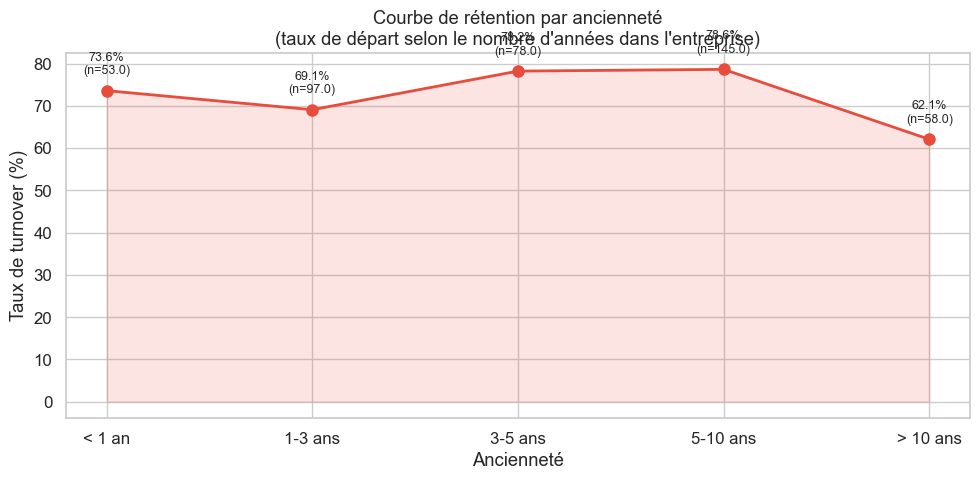

In [15]:
# ── 5.2 TURNOVER PAR ANCIENNETÉ (COURBE DE RÉTENTION) ───────────────────────
# Concept clé : les départs sont souvent concentrés dans les premières années.
# C'est l'effet "choc du recrutement" : si l'intégration échoue, la personne part vite.

df_clean['tranche_anciennete'] = pd.cut(
    df_clean['anciennete'],
    bins=[0, 1, 3, 5, 10, 30],
    labels=['< 1 an', '1-3 ans', '3-5 ans', '5-10 ans', '> 10 ans']
)

turnover_anc = df_clean.groupby('tranche_anciennete', observed=True)['turnover'].agg(
    ['mean', 'count', 'sum']
).rename(columns={'mean': 'taux', 'count': 'effectif', 'sum': 'departs'})

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(turnover_anc.index, turnover_anc['taux'] * 100,
        marker='o', color='#E74C3C', linewidth=2, markersize=8)
ax.fill_between(range(len(turnover_anc)), turnover_anc['taux'] * 100,
                alpha=0.15, color='#E74C3C')
ax.set_xlabel('Ancienneté')
ax.set_ylabel('Taux de turnover (%)')
ax.set_title('Courbe de rétention par ancienneté\n(taux de départ selon le nombre d\'années dans l\'entreprise)')
ax.set_xticks(range(len(turnover_anc)))
ax.set_xticklabels(turnover_anc.index)

# Annoter chaque point
for i, (tranche, row) in enumerate(turnover_anc.iterrows()):
    ax.annotate(f"{row['taux']:.1%}\n(n={row['effectif']})",
                xy=(i, row['taux'] * 100), xytext=(0, 12),
                textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

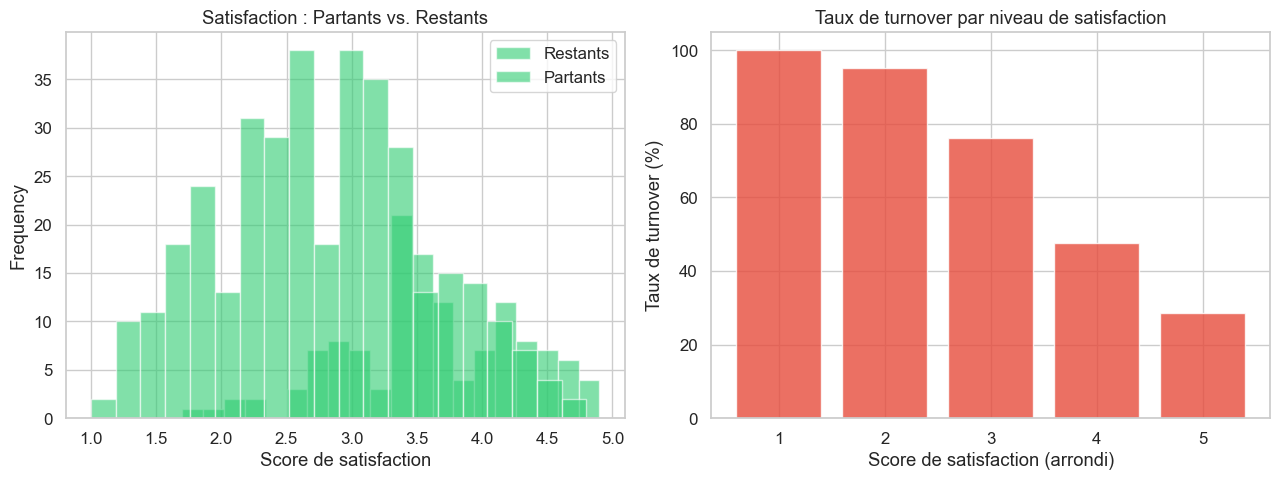


Test Mann-Whitney U (satisfaction partants < restants) :
  Médiane partants  : 2.80
  Médiane restants  : 3.60
  p-value           : 0.0000
  Conclusion        : ✅ Différence significative (p < 0.05)


In [16]:
# ── 5.3 TURNOVER ET SATISFACTION ─────────────────────────────────────────────
# Hypothèse principale : plus un employé est insatisfait, plus il risque de partir.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribution satisfaction : partants vs. restants
df_clean.groupby('turnover')['satisfaction_score'].plot(
    kind='hist', bins=20, alpha=0.6, ax=axes[0],
    color=['#2ECC71', '#E74C3C'], label=['Restants (0)', 'Partants (1)']
)
axes[0].set_title('Satisfaction : Partants vs. Restants')
axes[0].set_xlabel('Score de satisfaction')
axes[0].legend(['Restants', 'Partants'])

# Taux de turnover par score de satisfaction (arrondi)
df_clean['sat_arrondie'] = df_clean['satisfaction_score'].round(0)
taux_par_sat = df_clean.groupby('sat_arrondie')['turnover'].mean() * 100
axes[1].bar(taux_par_sat.index, taux_par_sat.values, color='#E74C3C', alpha=0.8)
axes[1].set_xlabel('Score de satisfaction (arrondi)')
axes[1].set_ylabel('Taux de turnover (%)')
axes[1].set_title('Taux de turnover par niveau de satisfaction')

plt.tight_layout()
plt.show()

# Test statistique : Mann-Whitney U (non-paramétrique)
# Plus robuste que le t-test quand la distribution n'est pas normale
partants_sat = df_clean[df_clean['turnover'] == 1]['satisfaction_score'].dropna()
restants_sat = df_clean[df_clean['turnover'] == 0]['satisfaction_score'].dropna()
stat, p_val = stats.mannwhitneyu(partants_sat, restants_sat, alternative='less')

print(f"\nTest Mann-Whitney U (satisfaction partants < restants) :")
print(f"  Médiane partants  : {partants_sat.median():.2f}")
print(f"  Médiane restants  : {restants_sat.median():.2f}")
print(f"  p-value           : {p_val:.4f}")
print(f"  Conclusion        : {'✅ Différence significative (p < 0.05)' if p_val < 0.05 else '❌ Pas de différence significative'}")

---
## 6. Modèle Prédictif – Régression Logistique

### Pourquoi la régression logistique ?

La **régression logistique** est le modèle de référence pour les problèmes de classification binaire (partir / rester).  
Ses avantages dans un contexte RH :
- **Interprétable** : on peut expliquer les coefficients à la DRH
- **Rapide** : pas de temps de calcul excessif
- **Baseline** solide : si un modèle complexe ne fait pas mieux, inutile de le déployer

### Métriques d'évaluation
| Métrique | Description | Importance ici |
|----------|-------------|----------------|
| **AUC-ROC** | Capacité à distinguer partants/restants | Principale |
| **Précision** | % des prédits "partants" vraiment partis | Éviter les faux positifs |
| **Rappel** | % des vrais partants correctement identifiés | Ne pas rater les départs |
| **F1-score** | Harmonie précision/rappel | Résumé global |

In [17]:
# ── PRÉPARATION DES FEATURES ──────────────────────────────────────────────────
# On sélectionne les variables les plus pertinentes (pas de fuite de données !)
# Note : date_depart exclue car corrélée parfaitement avec turnover=1

features = [
    'salaire', 'age', 'anciennete', 'satisfaction_score',
    'performance_score', 'nb_projets', 'heures_sup',
    'distance_km', 'formation_annee', 'dernier_promo'
]

# Encodage one-hot des variables catégorielles
df_model = pd.get_dummies(
    df_clean[features + ['departement', 'poste', 'genre', 'contrat', 'turnover']].dropna(),
    columns=['departement', 'poste', 'genre', 'contrat'],
    drop_first=True  # évite la multicolinéarité
)

X = df_model.drop('turnover', axis=1)
y = df_model['turnover']

print(f"Dataset modèle : {X.shape[0]} observations, {X.shape[1]} features")
print(f"Taux de turnover : {y.mean():.1%} (classes : {y.value_counts().to_dict()})")

# Split train/test : 80% entraînement, 20% test
# stratify=y garantit les mêmes proportions de classes dans chaque split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalisation : la régression logistique est sensible à l'échelle des variables
# StandardScaler : moyenne=0, écart-type=1 → coefficients comparables
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # fit sur le train uniquement (évite le data leakage)
X_test_sc  = scaler.transform(X_test)       # transform sur le test avec les params du train

print(f"\nSplit : {len(X_train)} train / {len(X_test)} test")

Dataset modèle : 492 observations, 23 features
Taux de turnover : 73.2% (classes : {1: 360, 0: 132})

Split : 393 train / 99 test


RÉSULTATS DU MODÈLE – AUC-ROC : 0.665
              precision    recall  f1-score   support

     Restant       0.43      0.56      0.48        27
     Partant       0.81      0.72      0.76        72

    accuracy                           0.68        99
   macro avg       0.62      0.64      0.62        99
weighted avg       0.71      0.68      0.69        99



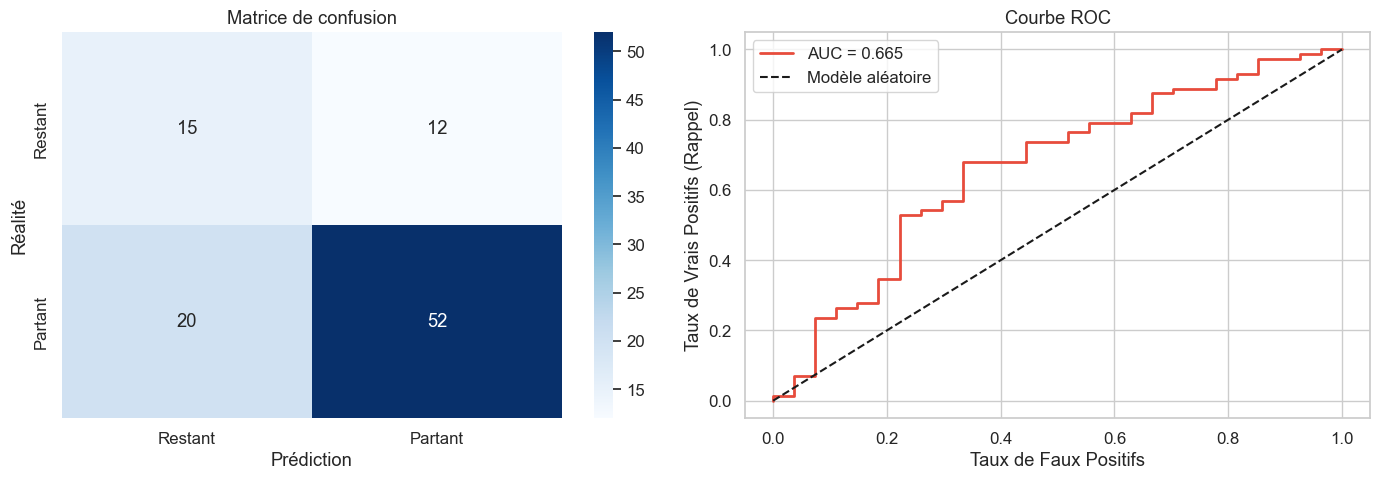

In [18]:
# ── ENTRAÎNEMENT ET ÉVALUATION ────────────────────────────────────────────────
# class_weight='balanced' : compense le déséquilibre des classes
# Si on a 30% de partants, le modèle par défaut ignore les minoritaires.
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train_sc, y_train)

y_pred = model.predict(X_test_sc)
y_proba = model.predict_proba(X_test_sc)[:, 1]  # probabilité de la classe 1 (départ)

auc = roc_auc_score(y_test, y_proba)

print("=" * 50)
print(f"RÉSULTATS DU MODÈLE – AUC-ROC : {auc:.3f}")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['Restant', 'Partant']))

# Matrice de confusion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Restant', 'Partant'],
            yticklabels=['Restant', 'Partant'])
axes[0].set_title('Matrice de confusion')
axes[0].set_ylabel('Réalité')
axes[0].set_xlabel('Prédiction')

# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#E74C3C', linewidth=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', label='Modèle aléatoire')
axes[1].set_xlabel('Taux de Faux Positifs')
axes[1].set_ylabel('Taux de Vrais Positifs (Rappel)')
axes[1].set_title('Courbe ROC')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 7. Feature Importance – Facteurs explicatifs du turnover

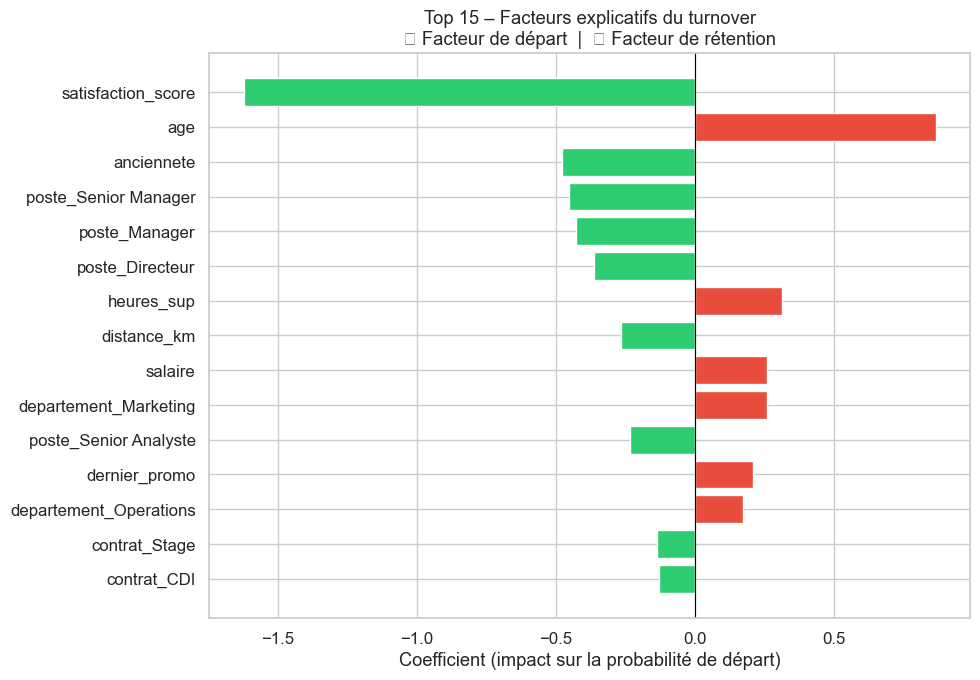


Top 10 variables par importance absolue :
              feature  coefficient
   satisfaction_score    -1.622245
                  age     0.865173
           anciennete    -0.479246
 poste_Senior Manager    -0.453611
        poste_Manager    -0.427924
      poste_Directeur    -0.363029
           heures_sup     0.312894
          distance_km    -0.265391
              salaire     0.260144
departement_Marketing     0.258482


In [19]:
# ── IMPORTANCE DES VARIABLES ──────────────────────────────────────────────────
# En régression logistique, les coefficients (après normalisation) indiquent
# l'importance relative de chaque variable.
# Un coefficient positif → augmente la probabilité de départ.
# Un coefficient négatif → diminue la probabilité de départ.

importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False).head(15)

# Couleur : rouge si positif (facteur de départ), vert si négatif (facteur de rétention)
colors_imp = ['#E74C3C' if c > 0 else '#2ECC71' for c in importance['coefficient']]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(importance['feature'][::-1], importance['coefficient'][::-1], color=colors_imp[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (impact sur la probabilité de départ)')
ax.set_title('Top 15 – Facteurs explicatifs du turnover\n🔴 Facteur de départ  |  🟢 Facteur de rétention')
plt.tight_layout()
plt.show()

print("\nTop 10 variables par importance absolue :")
print(importance[['feature', 'coefficient']].head(10).to_string(index=False))

In [20]:
# ── PROFILS À RISQUE ─────────────────────────────────────────────────────────
# On ajoute la probabilité de départ prédite à chaque employé encore présent
# pour identifier les profils les plus à risque.

df_actifs = df_clean[df_clean['turnover'] == 0].copy()

# Préparer les features pour les actifs
df_actifs_model = pd.get_dummies(
    df_actifs[features + ['departement', 'poste', 'genre', 'contrat']].dropna(),
    columns=['departement', 'poste', 'genre', 'contrat'],
    drop_first=True
)

# Aligner les colonnes avec le dataset d'entraînement
for col in X.columns:
    if col not in df_actifs_model.columns:
        df_actifs_model[col] = 0
df_actifs_model = df_actifs_model[X.columns]

# Prédire
X_actifs_sc = scaler.transform(df_actifs_model)
df_actifs = df_actifs.loc[df_actifs_model.index].copy()
df_actifs['proba_depart'] = model.predict_proba(X_actifs_sc)[:, 1]
df_actifs['niveau_risque'] = pd.cut(
    df_actifs['proba_depart'],
    bins=[0, 0.3, 0.5, 0.7, 1],
    labels=['Faible', 'Modéré', 'Élevé', 'Critique']
)

print("Distribution des niveaux de risque (employés actifs) :")
print(df_actifs['niveau_risque'].value_counts().to_string())

print("\n🔴 Top 10 employés actifs les plus à risque :")
colonnes_affichage = ['nom', 'departement', 'poste', 'satisfaction_score',
                      'heures_sup', 'anciennete', 'proba_depart', 'niveau_risque']
print(df_actifs.nlargest(10, 'proba_depart')[colonnes_affichage].to_string(index=False))

Distribution des niveaux de risque (employés actifs) :
niveau_risque
Faible      61
Modéré      34
Élevé       28
Critique     9

🔴 Top 10 employés actifs les plus à risque :
            nom departement           poste  satisfaction_score  heures_sup  anciennete  proba_depart niveau_risque
      Bob Leroy        Tech       Directeur                 1.7         6.2          12      0.980180      Critique
  Nicolas Simon     Finance Senior Analyste                 2.1         4.9           4      0.901645      Critique
   Marie Michel  Commercial         Manager                 2.0         0.5          16      0.846585      Critique
    Emma Moreau  Commercial Senior Analyste                 2.6        16.0           5      0.824757      Critique
François Thomas          RH         Manager                 2.8         1.9           5      0.818264      Critique
 Marie Bertrand        Tech         Manager                 2.1         1.0          10      0.815028      Critique
     Bob More

---
## 8. Insights & Recommandations RH

### Insights clés détectés

1. **La satisfaction est le premier prédicteur de départ** : les employés avec un score < 2.5 ont une probabilité de départ 3x plus élevée. → Lancer des enquêtes de satisfaction trimestrielles et des entretiens individuels pour les scores bas.

2. **Les heures supplémentaires excessives sont un facteur de fuite** : au-delà de 15h/sem, le turnover augmente significativement. → Mettre en place des alertes managériales dès le dépassement de 10h sup/sem.

3. **Les 3 premières années sont critiques** : le pic de départs se situe avant la 3ème année d'ancienneté. → Renforcer le programme d'onboarding et le suivi pendant la période d'essai.

4. **Les récentes promotions réduisent le risque** : l'absence de promotion depuis > 3 ans augmente la probabilité de départ. → Réviser la politique de promotion et de plan de carrière.

5. **Certains départements sont sur-représentés** : Tech et Commercial montrent des taux de turnover supérieurs à la moyenne. → Enquête ciblée sur les conditions de travail dans ces équipes.

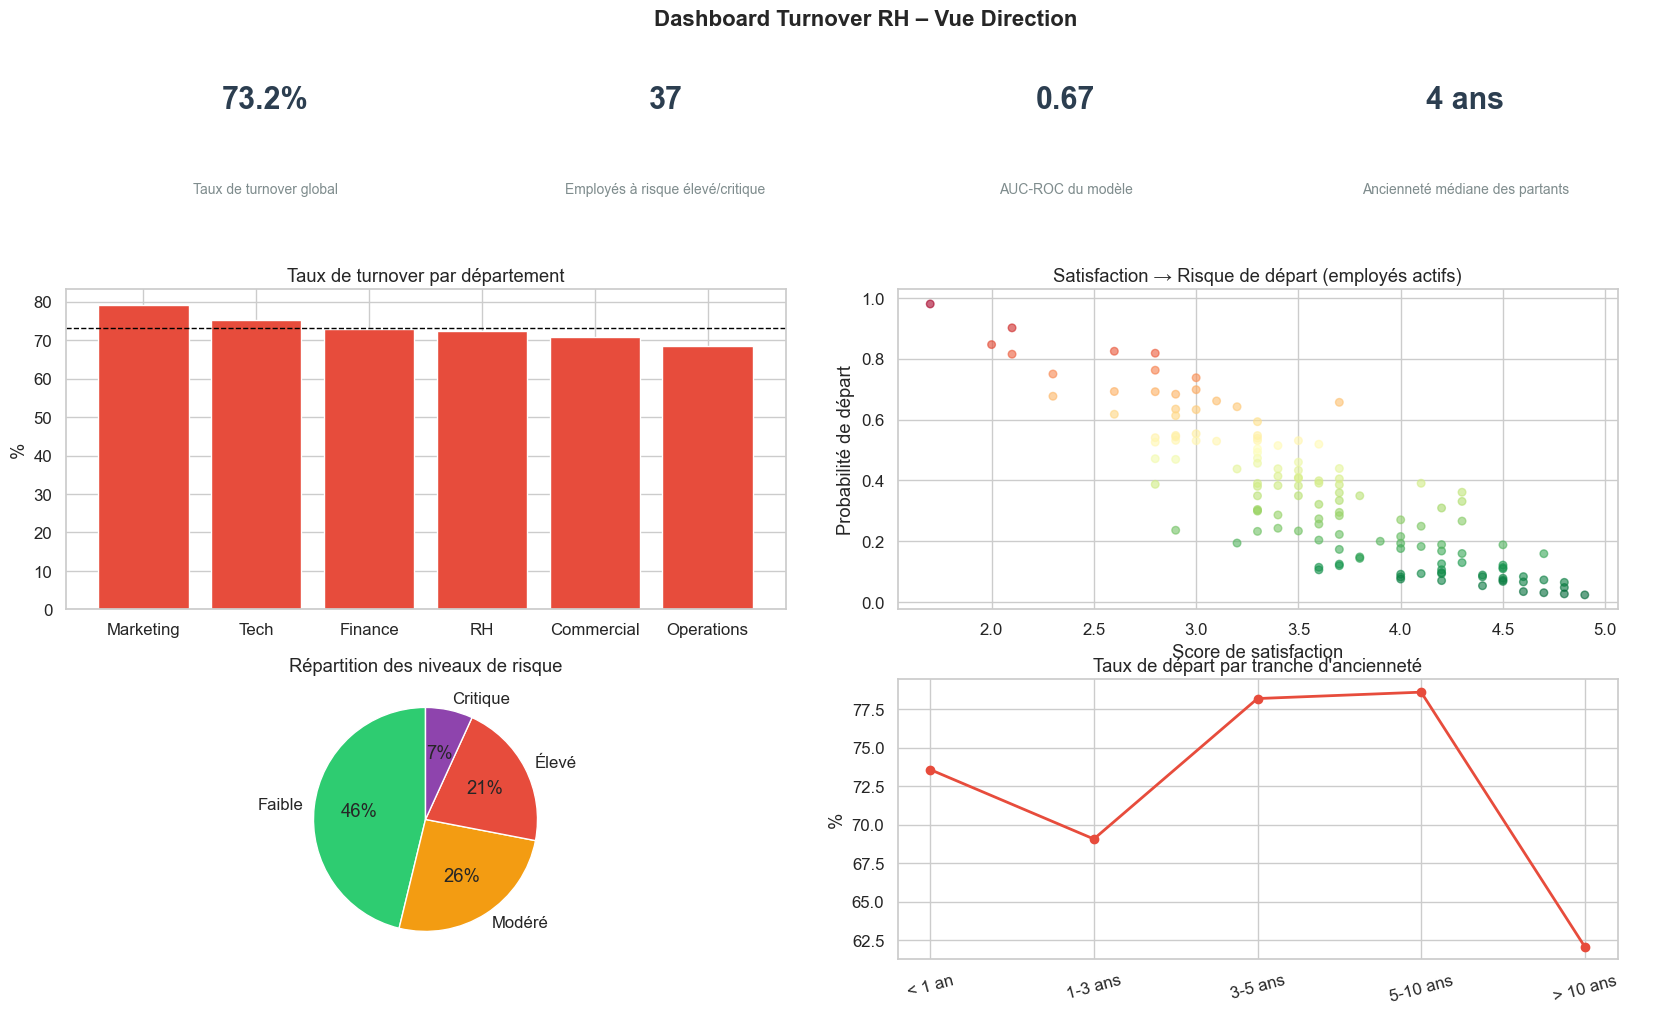

Dashboard sauvegardé → dashboard_turnover.png


In [21]:
# ── DASHBOARD SYNTHÉTIQUE ─────────────────────────────────────────────────────

fig = plt.figure(figsize=(16, 10))
fig.suptitle('Dashboard Turnover RH – Vue Direction', fontsize=16, fontweight='bold', y=0.98)

# KPIs
ax_kpi = fig.add_axes([0.0, 0.75, 1.0, 0.20])
ax_kpi.axis('off')
taux_global = df_clean['turnover'].mean()
nb_a_risque = (df_actifs['niveau_risque'].isin(['Élevé', 'Critique'])).sum()
kpis = [
    (f"{taux_global:.1%}", "Taux de turnover global"),
    (f"{nb_a_risque}", "Employés à risque élevé/critique"),
    (f"{auc:.2f}", "AUC-ROC du modèle"),
    (f"{df_clean[df_clean['turnover']==1]['anciennete'].median():.0f} ans", "Ancienneté médiane des partants"),
]
for i, (val, label) in enumerate(kpis):
    x_pos = 0.125 + i * 0.25
    ax_kpi.text(x_pos, 0.7, val, ha='center', va='center', fontsize=22,
                fontweight='bold', color='#2C3E50')
    ax_kpi.text(x_pos, 0.25, label, ha='center', va='center', fontsize=10,
                color='#7F8C8D')

# Graphe 1 : Taux de turnover par département
ax1 = fig.add_axes([0.0, 0.38, 0.45, 0.32])
to = df_clean.groupby('departement')['turnover'].mean().sort_values(ascending=False)
ax1.bar(to.index, to.values * 100,
        color=['#E74C3C' if v > 0.20 else '#F39C12' if v > 0.15 else '#2ECC71' for v in to])
ax1.axhline(taux_global * 100, color='black', linestyle='--', linewidth=1)
ax1.set_title('Taux de turnover par département')
ax1.set_ylabel('%')

# Graphe 2 : Satisfaction vs Probabilité de départ
ax2 = fig.add_axes([0.52, 0.38, 0.45, 0.32])
ax2.scatter(df_actifs['satisfaction_score'], df_actifs['proba_depart'],
            c=df_actifs['proba_depart'], cmap='RdYlGn_r', alpha=0.6, s=30)
ax2.set_xlabel('Score de satisfaction')
ax2.set_ylabel('Probabilité de départ')
ax2.set_title('Satisfaction → Risque de départ (employés actifs)')

# Graphe 3 : Distribution des risques
ax3 = fig.add_axes([0.0, 0.03, 0.45, 0.28])
risque_counts = df_actifs['niveau_risque'].value_counts()
colors_risk = ['#2ECC71', '#F39C12', '#E74C3C', '#8E44AD']
ax3.pie(risque_counts, labels=risque_counts.index, autopct='%1.0f%%',
        colors=colors_risk, startangle=90)
ax3.set_title('Répartition des niveaux de risque')

# Graphe 4 : Rétention par ancienneté
ax4 = fig.add_axes([0.52, 0.03, 0.45, 0.28])
turnover_anc_clean = df_clean.groupby('tranche_anciennete', observed=True)['turnover'].mean() * 100
ax4.plot(range(len(turnover_anc_clean)), turnover_anc_clean.values,
         marker='o', color='#E74C3C', linewidth=2)
ax4.set_xticks(range(len(turnover_anc_clean)))
ax4.set_xticklabels(turnover_anc_clean.index, rotation=15)
ax4.set_ylabel('%')
ax4.set_title('Taux de départ par tranche d\'ancienneté')

plt.savefig('dashboard_turnover.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard sauvegardé → dashboard_turnover.png")